#  强化学习框架
想象一下，你正在教一只小狗学习坐下这个指令。你不会直接告诉它坐下这个动作的每一个肌肉该如何运动，而是会这样做：

- 你发出坐下的口令。
- 小狗尝试做出某个动作（可能是坐下，也可能是趴下或转圈）。
- 如果它坐下了，你立刻给它一块零食作为奖励。
- 如果它做错了，你就不给奖励，或者发出一个轻微的不对的信号。
- 经过多次尝试，小狗会逐渐明白：听到坐下后做出坐下的动作，就能获得零食。于是它学会了这个指令。

强化学习 就是让计算机（或智能体）像这只小狗一样，通过与环境互动、根据获得的奖励或惩罚来学习如何做出一系列决策，以达成某个长期目标。

它与我们熟悉的监督学习（有标准答案的"老师"）和无监督学习（寻找数据内在结构）有本质区别。强化学习是从经验中学习，核心是试错与延迟奖励。

-----

## 强化学习的核心要素
为了形式化地描述这个学习过程，我们引入几个核心概念，它们共同构成了强化学习的基本框架。


### 智能体（Agent）与  环境（Environment）
- **智能体**：执行动作的主体，负责学习和决策。在上面的例子中，小狗就是智能体。在计算机中，它可以是一个算法、一个程序或一个机器人。
- **环境**：智能体所处的世界，智能体通过与环境互动来学习。在例子中，环境包括小狗所在的房间、零食、以及所有与小狗互动的元素。

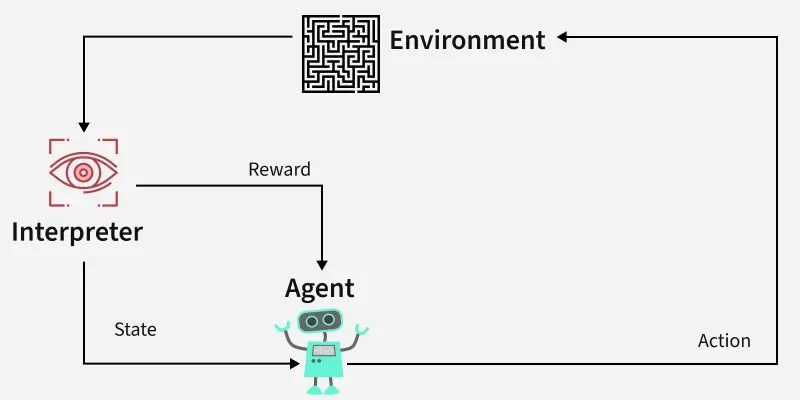

它们的关系是 : 智能体观察环境 -> 选择动作 -> 执行动作 -> 环境反馈新的状态和奖励 -> 智能体继续观察环境...



### 状态（State）, 动作（Action）与 奖励（Reward）
- **状态**：环境在某一时刻的具体情况。对于小狗来说，状态可能包括它的位置、是否听到指令、是否看到零食等。
- **动作**：智能体可以执行的行为。在例子中，动作可能是坐下、趴下、转圈等。
- **奖励**：环境对智能体动作的反馈，通常是一个数值，表示动作的好坏。奖励可以是正的（奖励）或负的（惩罚）。在例子中，坐下得到零食是正奖励，做错动作可能没有奖励或得到负奖励。

### 策略（Policy）, 价值函数（Value Function）与 模型（Model）
- **策略**：策略 是智能体的大脑或行为准则。它定义了在任意给定状态下，智能体应该采取哪个动作。策略可以是一个简单的查表函数，也可以是一个复杂的深度神经网络。强化学习的终极目标，就是找到一个最优策略，使得智能体从环境中获得的长期累积奖励最大化。
- **价值函数**：评估在某一状态下，智能体能够获得的预期奖励总和。它帮助智能体判断哪些状态是有价值的，从而指导策略的优化。
- **模型**：智能体对环境的理解和预测能力。它可以预测环境在智能体执行某个动作后会转移到哪个新状态，以及会获得什么奖励。模型可以帮助智能体进行规划和决策。

----

## 核心互动流程 : 马尔可夫决策过程（MDP）
强化学习的核心互动流程可以用一个叫做马尔可夫决策过程（MDP）的数学框架来描述。MDP由以下元素组成：
- **状态空间（S）**：所有可能的状态的集合。
- **动作空间（A）**：所有可能的动作的集合。
- **转移概率（P）**：描述在状态s下执行动作a后转移到新状态s'的概率。
- **奖励函数（R）**：描述在状态s下执行动作a后获得奖励r的函数。
- **折扣因子（γ）**：一个介于0和1之间的数，表示未来奖励的重要程度。

MDP 的核心思想是：下一个状态和奖励只取决于当前状态和当前采取的动作，与之前的历史无关（即马尔可夫性）。

一次完整的 MDP 交互周期如下：
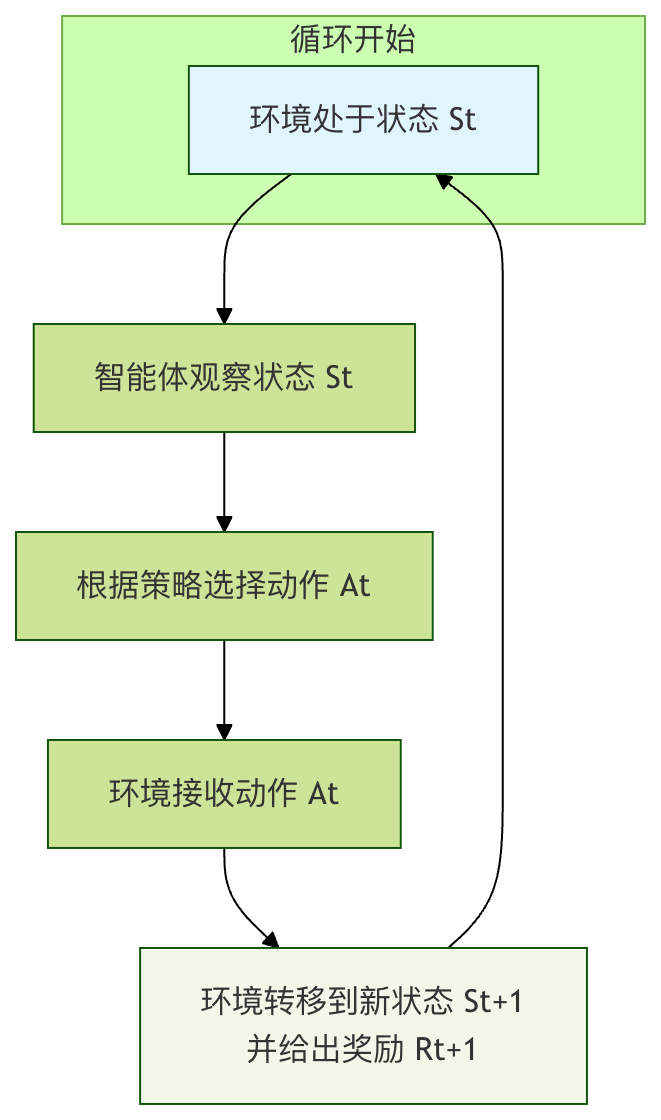

- 在时刻 t，环境处于状态 S_t。
- 智能体观察到这个状态。
- 智能体根据其策略 π，选择一个动作 A_t。
- 环境接收到这个动作。
- 环境根据其内在的动态规律，转移到下一个状态 S_{t+1}，并产生一个标量奖励 R_{t+1}，反馈给智能体。
- 时间步前进 (t = t+1)，新的循环开始。


In [19]:
import numpy as np
import random
from typing import List, Tuple , Dict


# ========= 1. 环境模拟(网络世界) ===========
class GridWorldEnv:
    """简单的网络世界环境 , 用于演示 Q-Learning"""
    def __init__(self , grid_size : Tuple[int , int] = (5 , 5),
                        start_pos : Tuple[int , int] = (0 , 0),
                        goal_pos : Tuple[int , int] = (4 , 4),
                        obstacle_pos : List[Tuple[int , int]] = [(1 , 1) , (2 , 2) , (3 , 1)]):
        self.grid_size = grid_size
        self.start_pos = start_pos
        self.goal_pos = goal_pos
        self.obstacle_pos = obstacle_pos
        self.current_pos = start_pos

        self.actions = ['up' , 'down' , 'left' , 'right']
        self.num_actions = len(self.actions)

    def reset(self) -> int :
        """重置环境 , 返回初始状态的索引"""
        self.current_pos = self.start_pos
        return self.pos_to_state(self.current_pos)
    
    def pos_to_state(self , pos : Tuple[int , int]) -> int :
        """将坐标位置转换为状态索引  二维转换为一维"""
        return pos[0] * self.grid_size[1] + pos[1]
    
    def state_to_pos(self , state : int) -> Tuple[int , int]:
        """将状态索引转换为坐标位置"""
        return (state // self.grid_size[1] , state % self.grid_size[1])
    
    def random_action(self) -> int:
        """随机选择一个动作(探索)"""
        return random.randint(0 , self.num_actions - 1)
    
    def action_to_direction(self , action : int) -> str:
        """将动作索引转换为方向名称"""
        return self.actions[action]
    
    def step(self , action : int) -> Tuple[int , float , bool]:
        """
        执行动作，返回(next_state, reward, done)
        优化点：修复障碍物奖励无法触发的bug，简化逻辑判断
        """
        x , y = self.current_pos


        # 根据动作更新位置
        if action == 0:         # 上
            x = max(0 , x - 1)
        elif action == 1:       # 下
            x = min(self.grid_size[0] - 1 , x + 1)
        elif action == 2:       # 左
            y = max(0 , y - 1)
        elif action == 3:       # 右
            y = min(self.grid_size[1] - 1 , y + 1)

        # 检查是否碰到障碍物(核心修复 : 先记录是否碰到障碍物 , 再处理位置)
        new_pos = (x , y)
        hit_obstacle = False        # 标记是否碰到障碍物
        if new_pos in self.obstacle_pos:
            hit_obstacle = True         # 记录障碍物碰撞状态
            new_pos = self.current_pos          # 碰到障碍物 , 位置不变

        self.current_pos = new_pos
        next_state = self.pos_to_state(new_pos)

        # 计算奖励(基于提前记录的 hit_obstacle , 修复原逻辑矛盾)
        if new_pos == self.goal_pos:
            reward = 100.0          # 到达终点 , 大奖励
            done = True
        elif hit_obstacle:          # 基于标记判断 , 而非修改后的 new_pos
            reward = -50.0          # 碰到障碍物 , 惩罚
            done = False
        else:
            reward = -1.0           # 每走一步小惩罚 , 鼓励尽快到达终点
            done = False

        return next_state , reward , done
    

# ====================== 2. Q-Learning 主程序 ======================
if __name__ == "__main__":
    # 优化点1 : 固定随机种子 , 保证实验结果可以复现
    random_seed = 42
    random.seed(random_seed)
    np.random.seed(random_seed)

    # 初始化环境
    env = GridWorldEnv(
        grid_size=(5, 5),          # 5x5网格
        start_pos=(0, 0),          # 起点
        goal_pos=(4, 4),           # 终点
        obstacle_pos=[(1,1), (2,2), (3,1)]  # 障碍物位置
    )

    # 计算状态数量
    num_states = env.grid_size[0] * env.grid_size[1]
    num_actions = env.num_actions
    
    # 初始化 Q 表(动作价值函数) , 形状为 [状态数量 , 动作数量]
    Q_table = np.zeros([num_states , num_actions])

    # 定义超参数
    learning_rate = 0.1                 # 学习率
    discount_factor = 0.9               # 折扣因子
    epsilon = 0.1                       # 探索率
    total_episodes = 1000               # 训练次数

    # 训练过程
    # 进度条 (可选) : 使用 tqdm 库显示训练进度 , 需要安装 tqdm 包
    # from tqdm import tqdm
    # for episode in tqdm(range(total_episodes) , desc="Training"):
    for episode in range(total_episodes):
        state = env.reset()                 # 重置环境到起点 , 获取初始状态 S
        done = False                        # 标记本轮是否结束
        total_reward = 0                    # 记录本轮总奖励

        while not done:
            # 1. ε-贪婪策略选择动作    均匀分布
            if random.uniform(0 , 1) < epsilon:                 # random.uniform(a, b) 是一个用来生成 指定范围内浮点数（小数） 的函数。
                action = env.random_action()                    # 探索 : 随机选动作
            else:
                # 利用 : 选择 Q 值最高的动作 , 处理平局情况
                max_Q = np.max(Q_table[state])                   # 当前状态下的最大 Q 值
                best_actions = np.where(Q_table[state] == max_Q)[0]  # np.where(condition) 返回满足条件的元素的索引
                action = random.choice(best_actions)          # 如果有多个动作具有相同的最大 Q 值 , 随机选择一个
                
            # 2. 执行动作 , 获取下一个状态和奖励 , 与环境交互
            next_state , reward , done = env.step(action)
            total_reward += reward

            # 3. 更新 Q 表(核心 : 使用 Q-Learning 更新公式 , 而非简单的平均)
            # Q-Learning 更新公式 : Q(S , A) = Q(S , A) + α * [R + γ * max(Q(S' , A') - Q(S , A))]
            old_value = Q_table[state , action]          # 旧的 Q 值
            next_max = np.max(Q_table[next_state])      # 下一个状态的最大 Q 值
            
            # 计算目标值 : 当前奖励 + 折扣后的下一个状态的最大 Q 值
            target = reward + discount_factor * next_max
            # 更新 Q 值 : 旧值 + 学习率 * (目标 - 旧值)
            Q_table[state , action] = old_value + learning_rate * (target - old_value)

            # 4. 进入下一个状态
            state = next_state

        # 每 100 轮打印一次训练进度和总奖励
        if (episode + 1) % 100 == 0:
            print(f"Episode {episode + 1} / {total_episodes} , Total Reward: {total_reward}")


# ========================3. 提取最优策略========================
policy : Dict[int , str] = {}
print("\n==学习到的最优策略==")

# 优化点2 : 按网格格式打印策略 , 增强可读性
grid_rows , grid_cols = env.grid_size
for row in range(grid_rows):
    row_str = []
    for col in range(grid_cols):
        pos = (row , col)
        state = env.pos_to_state(pos)
        if pos in env.obstacle_pos:
            row_str.append(" 障碍物 ")          # 障碍物
        elif pos == env.goal_pos:
            row_str.append("  终点  ")          # 终点
        elif pos == env.start_pos:
            # 同时标记起点和最优动作 , 以增强可读性
            # np.argmax() 返回指定数组中最大值的索引 , 这里用于获取当前状态下 Q 值最高的动作索引
            best_action_idx = np.argmax(Q_table[state])  # 最优动作索引
            best_action = env.action_to_direction(best_action_idx)  # 将动作索引转换为字符串
            row_str.append(f"  起点{best_action}  ")          # 起点
        else:
            best_action_idx = np.argmax(Q_table[state])  # 最优动作索引
            best_action = env.action_to_direction(best_action_idx)  # 将动作索引转换为字符串
            policy[state] = best_action  # 存储最优策略
            row_str.append(f" {best_action} ")          # 最优动作

    for i in range(len(row_str)):
        row_str[i] = row_str[i].center(8)  # 每个单元格宽度为8字符 , 居中显示
    print(" | ".join(row_str))  # 使用竖线分隔每个单元格


# ====================== 4. 测试最优策略 ======================
print("\n=== 测试最优策略 ===")
state = env.reset()
done = False
steps = 0
path = [env.state_to_pos(state)]

while not done and steps < 50:  # 最多50步，防止无限循环
    best_action_idx = np.argmax(Q_table[state])
    next_state, reward, done = env.step(best_action_idx)
    current_pos = env.state_to_pos(next_state)
    path.append(current_pos)
    state = next_state
    steps += 1

print(f"路径: {path}")
print(f"到达终点步数: {steps}")
print(f"是否到达终点: {env.current_pos == env.goal_pos}")

Episode 100 / 1000 , Total Reward: 41.0
Episode 200 / 1000 , Total Reward: 93.0
Episode 300 / 1000 , Total Reward: 93.0
Episode 400 / 1000 , Total Reward: 92.0
Episode 500 / 1000 , Total Reward: 91.0
Episode 600 / 1000 , Total Reward: 93.0
Episode 700 / 1000 , Total Reward: 93.0
Episode 800 / 1000 , Total Reward: 93.0
Episode 900 / 1000 , Total Reward: 93.0
Episode 1000 / 1000 , Total Reward: 87.0

==学习到的最优策略==
  起点right   |  right   |  right   |   down   |   down  
   up    |   障碍物    |  right   |  right   |   down  
  down   |   left   |   障碍物    |  right   |   down  
  down   |   障碍物    |  right   |   down   |   down  
 right   |  right   |  right   |  right   |    终点   

=== 测试最优策略 ===
路径: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (1, 4), (2, 4), (3, 4), (4, 4)]
到达终点步数: 8
是否到达终点: True
